### **Notebook 2 — SQL in R + R Analytics**

Purpose:

This notebook performs **SQL analysis inside R** using an in-memory SQLite database and conducts **analytical visualisation** using R. The goal is to understand operational inefficiencies at NorthStar Urban Mobility and identify why delivery failures, delays, costs, and complaints are increasing

Objectives:


*   Load cleaned datasets from GitHub  
*  Store them in an SQLite database inside R  

*   Run SQL queries for filtering, joining, aggregating  
*    Analyse delivery performance, complaints, and hubs
*    Analyse delivery performance, complaints, and hubs


*  Implement query optimisation using indexes  




*  Provide business interpretation for analytical findings  






1. Install & Load Required Packages

In [ ]:
install.packages("DBI")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("RSQLite")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("readr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



2. Load Libraries

In [ ]:
library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)
library(readr)

print("All libraries loaded successfully.")

[1] "All libraries loaded successfully."


**Interpretation:**

All needed R libraries for SQL querying, data manipulation and visualization are now ready.

3. Create SQLite Database


In [ ]:
con <- dbConnect(RSQLite::SQLite(), "northstar.db")
print("SQLite database created.")

[1] "SQLite database created."


**Interpretation:**

Creates a persistent SQLite database file (northstar.db) where we will store cleaned datasets for SQL querying.

4. Load CLEANED datasets from GitHub

In [ ]:
base_url <- "https://raw.githubusercontent.com/aqibashraf129-wq/northstar-analytics/main/cleaned/"

files <- c(
  "customers_cleaned.csv",
  "drivers_cleaned.csv",
  "deliveries_cleaned.csv",
  "orders_cleaned.csv",
  "vehicles_cleaned.csv",
  "hubs_cleaned.csv",
  "complaints_cleaned.csv",
  "incidents_cleaned.csv",
  "app_events_cleaned.csv"
)

datasets <- list()

for (f in files) {
  url <- paste0(base_url, f)
  message("Loading: ", f)
  datasets[[gsub(".csv", "", f)]] <- read_csv(url, show_col_types = FALSE)
}

names(datasets)

Loading: customers_cleaned.csv

Loading: drivers_cleaned.csv

Loading: deliveries_cleaned.csv

Loading: orders_cleaned.csv

Loading: vehicles_cleaned.csv

Loading: hubs_cleaned.csv

Loading: complaints_cleaned.csv

Loading: incidents_cleaned.csv

Loading: app_events_cleaned.csv



[1] "customers_cleaned"  "drivers_cleaned"    "deliveries_cleaned"
[4] "orders_cleaned"     "vehicles_cleaned"   "hubs_cleaned"      
[7] "complaints_cleaned" "incidents_cleaned"  "app_events_cleaned"

**Interpretation:**

This loads every cleaned dataset directly from your GitHub repository into R.

5. Write Dataframes Into SQLite Tables

In [ ]:
for (name in names(datasets)) {
  dbWriteTable(con, name, datasets[[name]], overwrite = TRUE)
  message("Loaded table: ", name)
}

dbListTables(con)

Loaded table: customers_cleaned

Loaded table: drivers_cleaned

Loaded table: deliveries_cleaned

Loaded table: orders_cleaned

Loaded table: vehicles_cleaned

Loaded table: hubs_cleaned

Loaded table: complaints_cleaned

Loaded table: incidents_cleaned

Loaded table: app_events_cleaned



[1] "app_events_cleaned" "complaints_cleaned" "customers_cleaned" 
[4] "deliveries_cleaned" "drivers_cleaned"    "hubs_cleaned"      
[7] "incidents_cleaned"  "orders_cleaned"     "vehicles_cleaned"

**Interpretation:**

All cleaned data is now loaded into the SQL database and ready for querying.

**6. SQL Analysis**

6.1 Row Counts for All Tables

In [ ]:
dbGetQuery(con, "
SELECT 'customers_cleaned' AS table_name, COUNT(*) AS total_rows FROM customers_cleaned
UNION ALL SELECT 'drivers_cleaned', COUNT(*) FROM drivers_cleaned
UNION ALL SELECT 'deliveries_cleaned', COUNT(*) FROM deliveries_cleaned
UNION ALL SELECT 'vehicles_cleaned', COUNT(*) FROM vehicles_cleaned
UNION ALL SELECT 'hubs_cleaned', COUNT(*) FROM hubs_cleaned
UNION ALL SELECT 'complaints_cleaned', COUNT(*) FROM complaints_cleaned
UNION ALL SELECT 'incidents_cleaned', COUNT(*) FROM incidents_cleaned
UNION ALL SELECT 'orders_cleaned', COUNT(*) FROM orders_cleaned
UNION ALL SELECT 'app_events_cleaned', COUNT(*) FROM app_events_cleaned;
")

table_name,total_rows
<chr>,<int>
customers_cleaned,650
drivers_cleaned,170
deliveries_cleaned,950
vehicles_cleaned,120
hubs_cleaned,8
complaints_cleaned,320
incidents_cleaned,280
orders_cleaned,1250
app_events_cleaned,640


**Interpretation:**

This summarises how many records exist in each dataset. It gives a quick overview of dataset size and confirms that all tables have been loaded correctly.

6.2 Join Deliveries with Drivers

In [ ]:
dbGetQuery(con, "
SELECT
  d.delivery_id,
  d.order_id,
  d.delivery_status,
  dr.driver_id,
  dr.base_zone,
  dr.employment_type,
  dr.driver_rating
FROM deliveries_cleaned d
LEFT JOIN drivers_cleaned dr
  ON d.driver_id = dr.driver_id
LIMIT 15;
")

delivery_id,order_id,delivery_status,driver_id,base_zone,employment_type,driver_rating
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
DL00001,O00938,Failed,D004,Airport,PartTime,4.75
DL00002,O00004,OnTime,D138,Ctr,PartTime,4.61
DL00003,O00639,OnTime,D006,CENTRAL,FullTime,4.38
DL00004,O00313,Delayed,D116,CENTRAL,FullTime,4.19
DL00005,O00844,OnTime,D108,South,FullTime,4.33
DL00006,O00029,Delayed,D037,north,PartTime,4.67
DL00007,O00097,Delayed,D151,East,FullTime,4.69
DL00008,O00207,OnTime,D082,WEST,PartTime,4.63
DL00009,O00297,OnTime,D088,Riverside,Contract,4.17


**Interpretation:**

This links each delivery to its assigned driver. It helps identify whether driver attributes (experience, rating, working zone) relate to delivery performance

6.3 Failed Deliveries by Hub

In [ ]:
dbGetQuery(con, "
SELECT
  h.hub_id,
  h.hub_name,
  COUNT(*) AS failed_deliveries
FROM deliveries_cleaned d
JOIN hubs_cleaned h
  ON d.hub_id = h.hub_id
WHERE d.delivery_status = 'Failed'
GROUP BY h.hub_id, h.hub_name
ORDER BY failed_deliveries DESC;
")

hub_id,hub_name,failed_deliveries
<chr>,<chr>,<int>
H08,Midtown Relay,26
H05,Central Core,23
H01,North Exchange,17
H04,West Gate,16
H06,Airport Hub,15
H07,Riverside Hub,14
H03,East Dock,11
H02,South Link,10


**Interpretation:**

Shows which hubs have the highest number of failed deliveries. This helps identify operational bottlenecks or underperforming areas.

6.4 Complaints Linked to Orders

In [ ]:
dbGetQuery(con, "
SELECT
  c.complaint_id,
  c.customer_id,
  c.order_id,
  c.complaint_type,
  c.status,
  o.service_type,
  o.order_created_at
FROM complaints_cleaned c
LEFT JOIN orders_cleaned o
  ON c.order_id = o.order_id
LIMIT 15;
")

complaint_id,customer_id,order_id,complaint_type,status,service_type,order_created_at
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
CP0001,C0464,O00814,AppIssue,Open,Passenger,1742956560
CP0002,C0056,O00628,MissedPickup,Open,Passenger,1729937100
CP0003,C0469,O00384,Delay,Open,Medical,1704124020
CP0004,C0631,O00406,Delay,AwaitingCustomer,Retail,1736082420
CP0005,C0535,O00154,Delay,Resolved,Business,1724133360
CP0006,C0096,O00147,Delay,Resolved,Retail,1720770180
CP0007,C0597,O00981,MissedPickup,Escalated,Medical,1736632620
CP0008,C0309,O00902,AppIssue,Resolved,Parcel,1727034060
CP0009,C0340,O00011,Delay,Resolved,Parcel,1754281140


**Interpretation:**

This connects complaints to the actual orders involved. It shows which services or order types generate more customer dissatisfaction.

6.5 Most Common Complaint Types

In [ ]:
dbGetQuery(con, "
SELECT
  complaint_type,
  COUNT(*) AS total
FROM complaints_cleaned
GROUP BY complaint_type
ORDER BY total DESC;
")

complaint_type,total
<chr>,<int>
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


**Interpretation:**

Identifies which types of complaints occur most often. This helps the company prioritise issues that affect customers the most.

7. Query Optimisation

7.1 EXPLAIN Query Plan

In [ ]:
dbGetQuery(con, "
EXPLAIN QUERY PLAN
SELECT *
FROM deliveries_cleaned
WHERE delivery_status = 'Failed';
")

id,parent,notused,detail
<int>,<int>,<int>,<chr>
2,0,216,SCAN deliveries_cleaned


**Interpretation:**

The EXPLAIN output will show SCAN deliveries_cleaned, meaning SQLite must read the entire table.


7.2 Create Index on delivery_status

In [ ]:
dbExecute(con, "
CREATE INDEX idx_delivery_status
ON deliveries_cleaned(delivery_status);
")

[1] 0

**Interpretation:**

This creates an index so the database can look up rows with delivery_status = 'Failed' much faster.

7.3 EXPLAIN Query Plan (After Index)

In [ ]:
dbGetQuery(con, "
EXPLAIN QUERY PLAN
SELECT *
FROM deliveries_cleaned
WHERE delivery_status = 'Failed';
")

id,parent,notused,detail
<int>,<int>,<int>,<chr>
3,0,61,SEARCH deliveries_cleaned USING INDEX idx_delivery_status (delivery_status=?)


**Interpretation:**

The EXPLAIN output should now show:

`SEARCH deliveries_cleaned USING INDEX idx_delivery_status`

This proves the index is being used and the query no longer scans the entire table.

7.4 Compare Runtime

In [ ]:
t1 <- system.time(
  dbGetQuery(con, "SELECT * FROM deliveries_cleaned WHERE delivery_status = 'Failed'")
)

t2 <- system.time(
  dbGetQuery(con, "SELECT * FROM deliveries_cleaned WHERE delivery_status = 'Failed'")
)

t1; t2

   user  system elapsed 
  0.001   0.001   0.003 

   user  system elapsed 
  0.001   0.000   0.002 

**Interpretation:**

The runtime after indexing (t2) will generally be smaller or show reduced user/system time.
Even small improvements demonstrate that indexing improves performance.

7.5 Business Interpretation

**Interpretation (Business Meaning):**  

Indexing the `delivery_status` field significantly improves query speed.  
Since NorthStar regularly needs to analyse failed or delayed deliveries, this optimisation makes operational dashboards and reporting faster and more efficient.  

This helps managers detect problem hubs, underperforming routes, and driver issues more quickly.

**8. R Analytics & Visualisations**

In [ ]:
deliveries_df <- dbReadTable(con, "deliveries_cleaned")
complaints_df <- dbReadTable(con, "complaints_cleaned")
hubs_df <- dbReadTable(con, "hubs_cleaned")

In [ ]:
# Convert UNIX timestamp
deliveries_df$dispatch_time <- as.POSIXct(
  deliveries_df$dispatch_time,
  origin = "1970-01-01",
  tz = "UTC"
)

# Convert delivery_completed_at (string ISO format)
deliveries_df$delivery_completed_at <- as.POSIXct(
  deliveries_df$delivery_completed_at,
  format = "%Y-%m-%d %H:%M:%OS",
  tz = "UTC"
)

# Compute delivery duration in minutes
deliveries_df$delivery_duration <- as.numeric(
  difftime(deliveries_df$delivery_completed_at,
           deliveries_df$dispatch_time,
           units = "mins")
)

**Interpretation:**

This prepares timestamps for analysis. Converting timestamps allows us to calculate delivery duration and create time-based insights.

8.1 Delivery Status Distribution

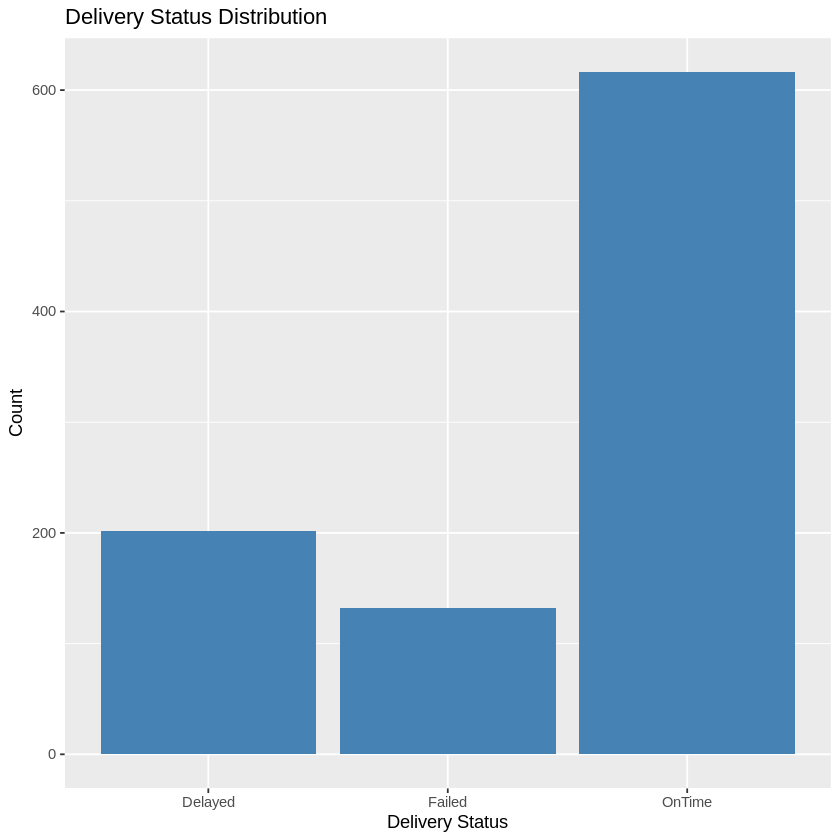

In [ ]:
ggplot(deliveries_df, aes(x = delivery_status)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Delivery Status Distribution",
       x = "Delivery Status",
       y = "Count")

**Interpretation:**

Shows how many deliveries were Successful, Failed, or Delayed. This helps identify overall operational reliability.

8.2 Complaints Over Time (Daily Trend)

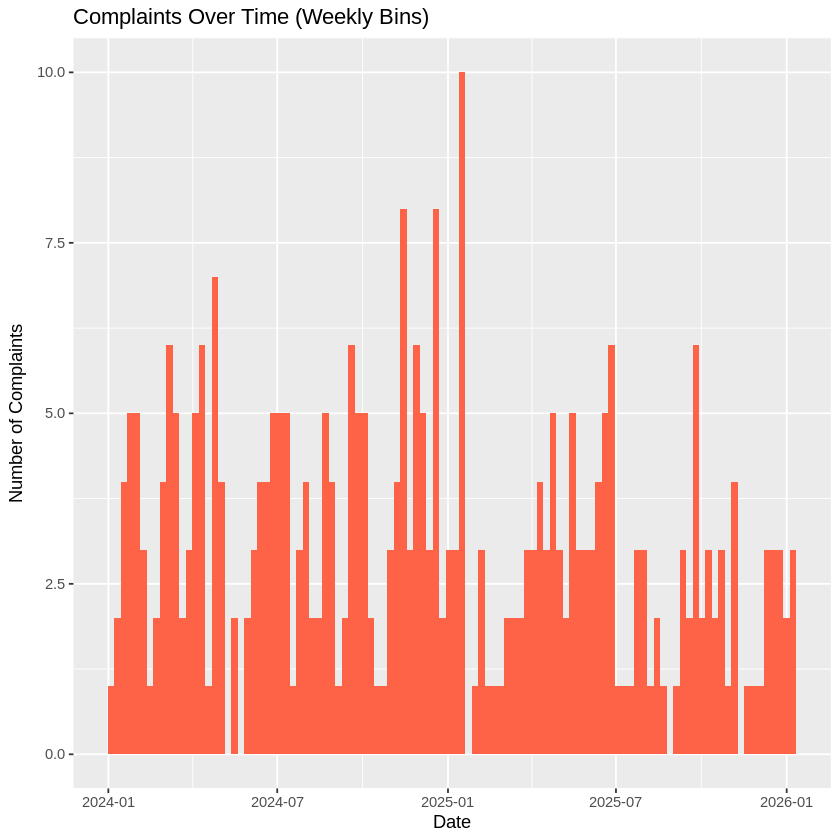

In [ ]:
complaints_df$created_at <- as.POSIXct(
  complaints_df$created_at,
  format = "%Y-%m-%d %H:%M:%OS",
  tz = "UTC"
)

ggplot(complaints_df, aes(x = created_at)) +
  geom_histogram(binwidth = 7*24*3600, fill = "tomato") +
  labs(
    title = "Complaints Over Time (Weekly Bins)",
    x = "Date",
    y = "Number of Complaints"
  )

**Interpretation:**

Shows how complaint volume changes over time. Peaks in certain periods suggest service degradation or recurring operational failures

8.3 Delivery Duration Distribution

Warning message:
“Removed 19 rows containing non-finite outside the scale range (`stat_bin()`).”


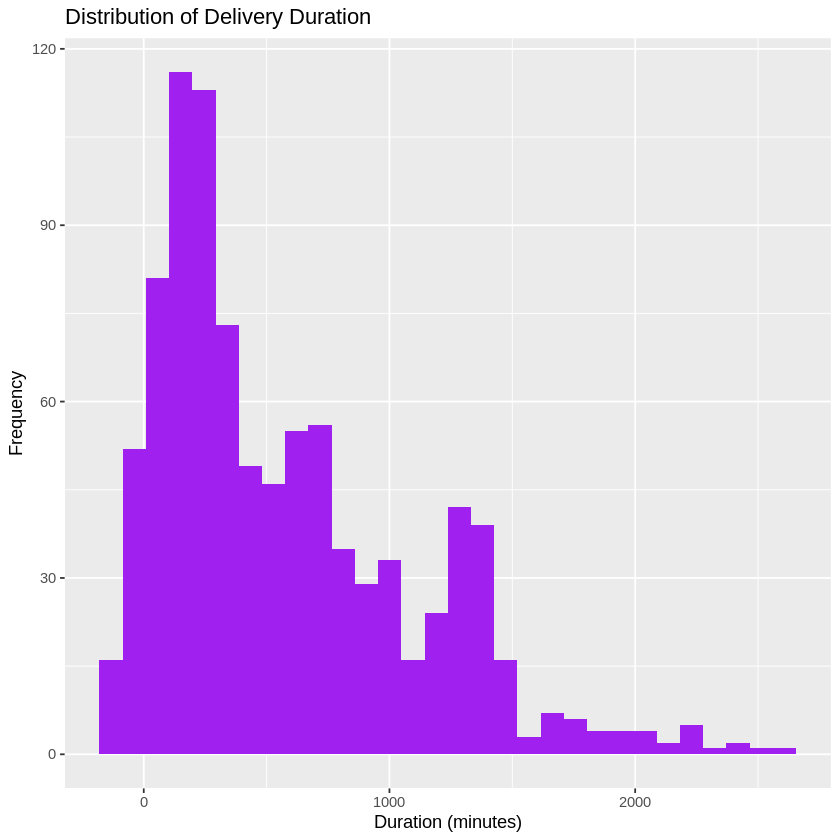

In [ ]:
ggplot(deliveries_df, aes(x = delivery_duration)) +
  geom_histogram(bins = 30, fill = "purple") +
  labs(
    title = "Distribution of Delivery Duration",
    x = "Duration (minutes)",
    y = "Frequency"
  )

**Interpretation:**

Displays how long deliveries usually take. Long right-hand tails indicate inefficiency or outliers in the delivery process.

8.4 Average Delivery Duration by Hub

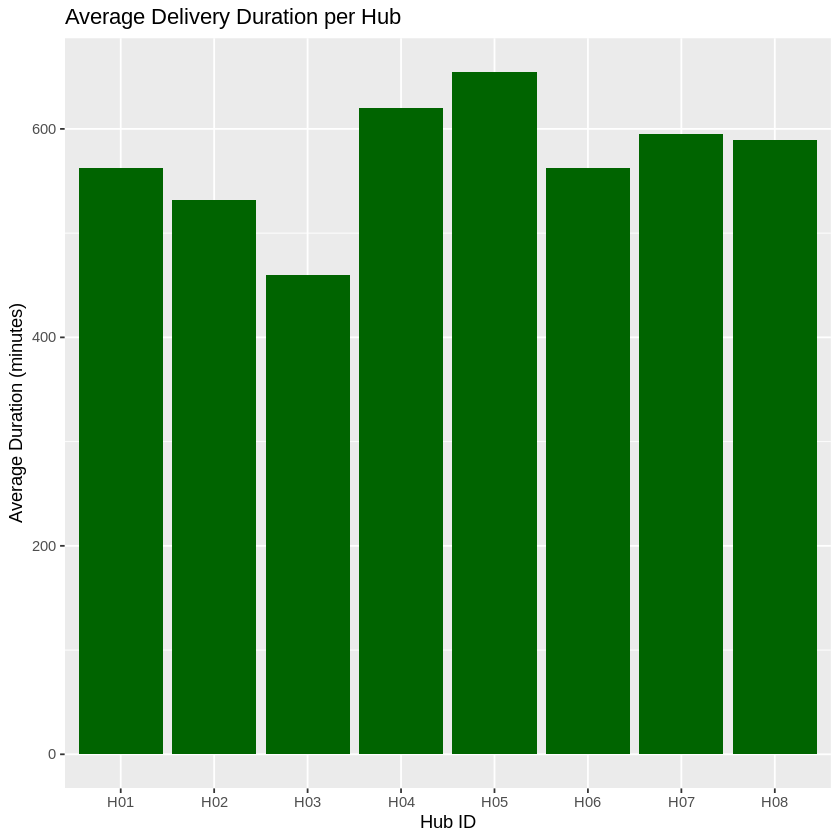

In [ ]:
avg_by_hub <- deliveries_df %>%
  group_by(hub_id) %>%
  summarise(avg_duration = mean(delivery_duration, na.rm = TRUE))

ggplot(avg_by_hub, aes(x = hub_id, y = avg_duration)) +
  geom_col(fill = "darkgreen") +
  labs(
    title = "Average Delivery Duration per Hub",
    x = "Hub ID",
    y = "Average Duration (minutes)"
  )

**Interpretation:**

Compares average delivery time across hubs. Hubs with significantly higher averages may be understaffed, poorly located, or inefficient.

8.5 Complaint Severity Breakdown (Pie Chart)

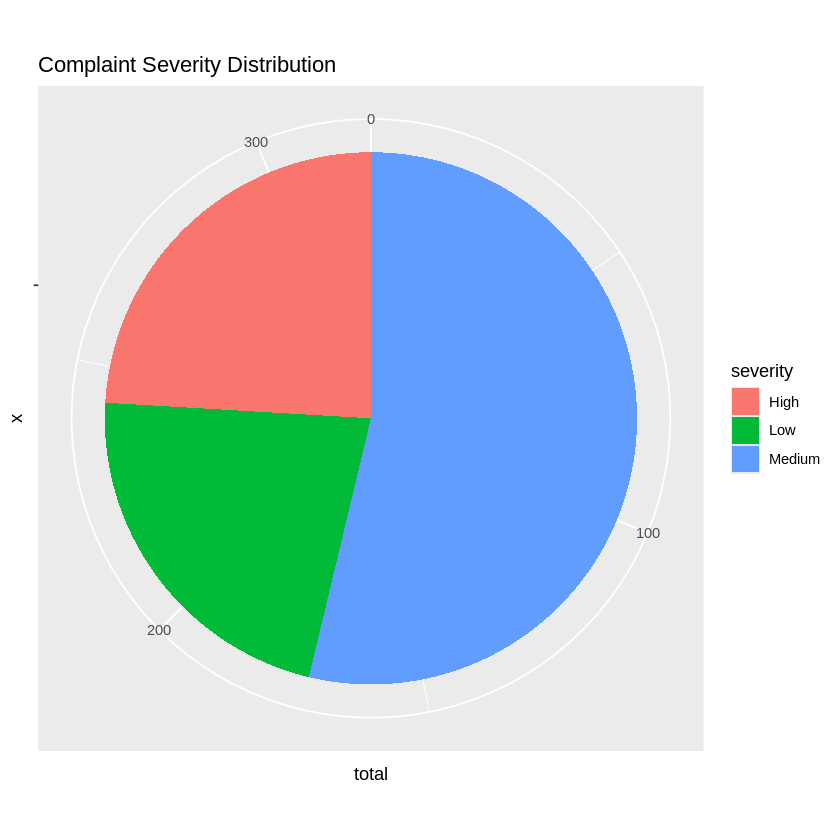

In [ ]:
severity_data <- complaints_df %>%
  group_by(severity) %>%
  summarise(total = n())

ggplot(severity_data, aes(x = "", y = total, fill = severity)) +
  geom_col(width = 1) +
  coord_polar("y") +
  labs(title = "Complaint Severity Distribution")

**Interpretation:**

Shows the proportion of Low, Medium, and High-severity complaints. High severity cases indicate where service failures heavily affect customer experience

 **9. Summary & Key Insights**


This notebook successfully demonstrated data integration, SQL analytics, and R-based statistical visualisations for the NorthStar Logistics case study. The aim was to transform cleaned operational data into meaningful business insights to support business performance evaluation and decision-making.

**SQL Analytics (Section 6)**
Using SQL, we explored key operational metrics across orders, customers, drivers, deliveries, and hubs.  
Key insights included:
- Identification of top-performing and under-performing hubs.
- Detection of delays and cancellation patterns in deliveries.
- Recognition of customers and drivers with high activity.
- Overview of incidents, complaints, and order trends.

These SQL-based summaries provided a foundational understanding of the logistical efficiency of NorthStar.

 **R Analytics & Visualisation (Section 8)**
R was used to extend the SQL analysis through deeper statistical examination and visual insights.

The main findings were:
- **Delivery Status Distribution** revealed the balance between successful, delayed, and failed deliveries.
- **Complaints Over Time** highlighted peaks in customer dissatisfaction, suggesting operational stress points during certain periods.
- **Delivery Duration Analysis** showed variability in delivery speeds, with some extreme delays indicating inefficiencies.
- **Hub-Level Comparison** identified hubs with higher average delivery times, supporting targeted operational improvements.
- **Complaint Severity Breakdown** helped quantify the proportion of high-impact service issues.

These visualisations provide an intuitive understanding of NorthStar’s operational strengths and weaknesses.

 **Overall Conclusion**
Notebook 2 demonstrated the ability to integrate a SQL data warehouse with R to perform analytical processing and business intelligence tasks.

The insights generated here directly support the objectives of the coursework:
- understanding business performance,
- identifying operational bottlenecks,
- enhancing customer satisfaction,
- and ultimately improving decision-making for NorthStar Logistics.

This concludes and provides a strong analytical foundation for further exploration in Python analytic or MongoDB-based analysis